<a href="https://colab.research.google.com/github/AshrfCode/Data-Mining-and-Machine-Learning/blob/main/lab3_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
from sklearn.cluster import KMeans
from scipy.stats import mode
import matplotlib.pyplot as plt
import numpy as np
import re

In [3]:
def readFile(fileName):
    file = open(fileName,'r',encoding="cp437")
    fileText = ""
    for line in file:
        fileText += line
    return fileText

In [4]:
def preProcess(text):
    # Remove non-letter chars
    text = re.sub("[^a-zA-Z ]"," ", text)
    # Change characters to lower
    text = text.lower()
    return text

In [5]:
def genReferenceWordList(texts,stopWords):
    # concatenate the texts
    allText = ""
    for line in texts:
        allText += line

    # Generate a word list
    wordsList =  allText.split()
    # Generate a word set
    wordsSet =  set(wordsList)

    # Remove the stop words from the word list
    stopWordsList = stopWords.split()
    stopWordsSet = set(stopWordsList)
    refWordSet = wordsSet.difference(stopWordsSet)
    return list(refWordSet)

In [6]:
def getWordFrequency(texts,refList):

    refListSize = len(refList)
    nTexts = len(texts)
    wordFreq = np.empty((nTexts,refListSize),dtype=np.int64)
    for i in range(nTexts):            # scan texts
        print("text" + str(i))
        for j in range(refListSize):      # scan words in dict
            wordFreq[i,j] = texts[i].count(refList[j])
    return wordFreq

In [7]:
def partitionText(text, windSize,label):
    nParts = len(text)//windSize
    chunks=[]
    labels = []
    for i in range(nParts):
        nextWind = i*windSize
        nextChunk = text[nextWind:nextWind+windSize]
        chunks += [nextChunk]
        labels += [label]
    return chunks,labels;

In [8]:
def plotLabels(labels,labelsType):

    plt.title("The " +  labelsType + " labels")
    plt.xlabel("partition#")
    plt.ylabel("label")
    plt.bar(range(len(labels)),labels)
    plt.show()

In [9]:
def rearangeLabels(trueLabels,predLabels,k):
    rearangedLabels = np.zeros(len(trueLabels))
    for i in range(k):
        predIs = np.where((i+1)==predLabels)[0]
        # Get the true labels in the predicted locations
        trueLabelsInLoc = trueLabels[predIs]
        # find the common label
        commonLabel,count = mode(trueLabelsInLoc)
        # put the comon true label in the predicted location
        rearangedLabels[predIs] = commonLabel
    return rearangedLabels

In [12]:
bookTexts = []

bookTexts += [readFile('DB.txt')]
bookTexts += [readFile('HP.txt')]
bookTexts += [readFile('Eliot.txt')]
bookTexts += [readFile('Tolkien.txt')]

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
texts = []
for text in bookTexts:
    texts += [preProcess(text)]

In [15]:
stopWords = readFile('stopwords_en.txt')

In [16]:
refList = genReferenceWordList(texts,stopWords)

In [ ]:
trueLabels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,

In [172]:
window = 13304
#partition the each file into chunks of the size wind
chunks = []
trueLabels = []
for i, text in enumerate(texts):
    newChunks,newLabels = partitionText(text , window,i+1)
    chunks += newChunks
    trueLabels+=newLabels
trueLabels = np.array(trueLabels)

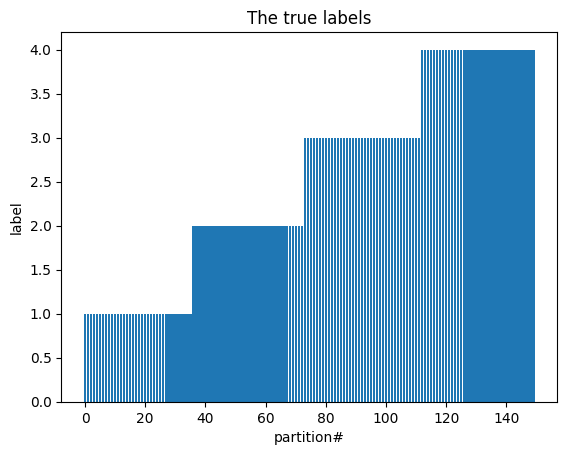

In [173]:
plotLabels(trueLabels,"true")

In [174]:
wordFreq = getWordFrequency(chunks,refList)

text0
text1
text2
text3
text4
text5
text6
text7
text8
text9
text10
text11
text12
text13
text14
text15
text16
text17
text18
text19
text20
text21
text22
text23
text24
text25
text26
text27
text28
text29
text30
text31
text32
text33
text34
text35
text36
text37
text38
text39
text40
text41
text42
text43
text44
text45
text46
text47
text48
text49
text50
text51
text52
text53
text54
text55
text56
text57
text58
text59
text60
text61
text62
text63
text64
text65
text66
text67
text68
text69
text70
text71
text72
text73
text74
text75
text76
text77
text78
text79
text80
text81
text82
text83
text84
text85
text86
text87
text88
text89
text90
text91
text92
text93
text94
text95
text96
text97
text98
text99
text100
text101
text102
text103
text104
text105
text106
text107
text108
text109
text110
text111
text112
text113
text114
text115
text116
text117
text118
text119
text120
text121
text122
text123
text124
text125
text126
text127
text128
text129
text130
text131
text132
text133
text134
text135
text136
text137
text13

In [175]:
k = len(bookTexts) # k: number of clusters
# define the k-means object
kmeans = KMeans(n_clusters = k)
# compute the k-means model of the chunks
kmeans.fit(wordFreq)

KMeans(n_clusters=4)

In [176]:
# predict the labels of the chunks
predLabels = kmeans.predict(wordFreq)
predLabels +=1

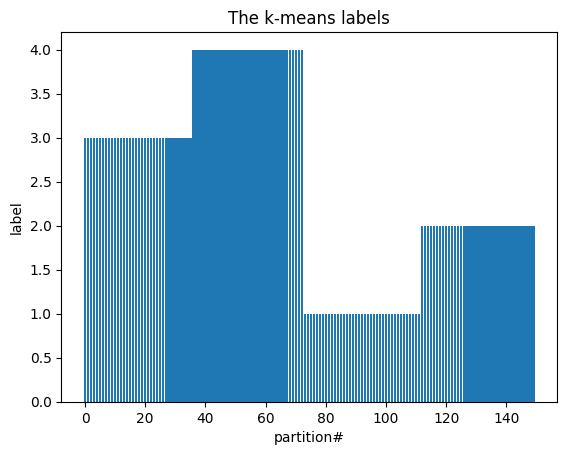

In [177]:
# plot the k-means prediction
plotLabels(predLabels,"k-means")

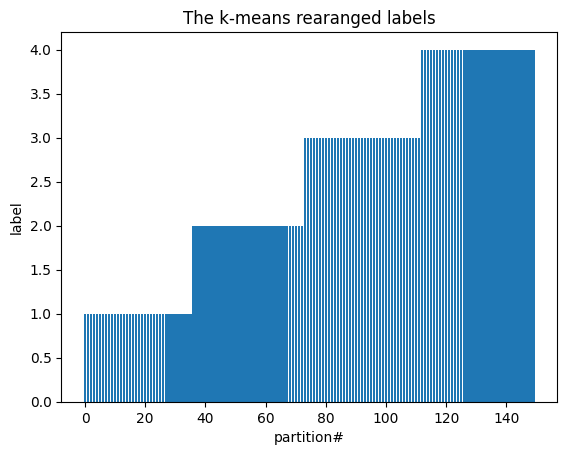

In [178]:
# rearange predicted labels according to the true labels
predictedLabels = rearangeLabels(trueLabels,predLabels,k)
plotLabels(predictedLabels,"k-means rearanged")

In [179]:
nErrors = np.sum(trueLabels!=predictedLabels)
nChunks = len(trueLabels)
accuracy = (nChunks - nErrors)/nChunks
print("The number of errors is",nErrors)
print("The kmeans accurcay for window size ",window, " is ", accuracy)

The number of errors is 0
The kmeans accurcay for window size  13304  is  1.0


# **New Code:**

# **PART 4**

In [ ]:
# Calculate errors per book
book_names = ['DB', 'HP', 'Eliot', 'Tolkien']

error_counts = []
for i in range(1, k + 1):
    mask = (trueLabels == i)
    book_errors = np.sum(trueLabels[mask] != predictedLabels[mask])
    total_chunks = np.sum(mask)
    error_counts.append(book_errors)
    print(f"{book_names[i-1]}: {book_errors} errors out of {total_chunks} chunks")

# Identify book with most errors
max_error_idx = np.argmax(error_counts)
print(f"\nBook with most errors: {book_names[max_error_idx]}")

# Inspect the errors for that book
error_indices = np.where((trueLabels == max_error_idx + 1) & (trueLabels != predictedLabels))[0]
print(f"Error indices: {error_indices}")

DB: 2 errors out of 96 chunks
HP: 3 errors out of 99 chunks
Eliot: 7 errors out of 104 chunks
Tolkien: 6 errors out of 101 chunks

Book with most errors: Eliot
Error indices: [240 248 255 277 279 280 281]


In [ ]:
trueLabels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,

In [ ]:
predLabels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 4, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4,
       4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 2, 1, 2, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1,

# Part 5

In [ ]:
# Test a broader range of window sizes to see the trend
window_sizes = [500, 1000, 2500, 5000, 10000, 30000]
accuracies = []

for w in window_sizes:
    temp_chunks = []
    temp_true_labels = []
    for i, text in enumerate(texts):
        new_c, new_l = partitionText(text, w, i + 1)
        temp_chunks += new_c
        temp_true_labels += new_l

    # Get frequencies
    temp_freq = getWordFrequency(temp_chunks, refList)

    # Run K-Means
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(temp_freq)
    pred = km.predict(temp_freq) + 1

    # Rearrange and calculate accuracy
    rearranged = rearangeLabels(np.array(temp_true_labels), pred, k)
    acc = np.sum(np.array(temp_true_labels) == rearranged) / len(temp_true_labels)
    accuracies.append(acc)
    print(f"Window size {w}: Accuracy = {acc:.4f}")

# Plot the relationship
plt.figure(figsize=(10, 6))
plt.plot(window_sizes, accuracies, marker='s', color='red', linestyle='--')
plt.title('How Window Size Affects Author Identification')
plt.xlabel('Window Size (Characters)')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

# **PART 6 Minimal Window Size**

In [ ]:
# Binary search for the minimal window size with 0 errors
low = 10000
high = 30000
min_win = high

while low <= high:
    mid = (low + high) // 2
    temp_chunks = []
    temp_true_labels = []
    for i, text in enumerate(texts):
        new_c, new_l = partitionText(text, mid, i + 1)
        temp_chunks += new_c
        temp_true_labels += new_l

    temp_freq = getWordFrequency(temp_chunks, refList)
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(temp_freq)
    pred = km.predict(temp_freq) + 1
    rearranged = rearangeLabels(np.array(temp_true_labels), pred, k)

    nErrors = np.sum(np.array(temp_true_labels) != rearranged)
    print(f"Testing window {mid}: {nErrors} errors")

    if nErrors == 0:
        min_win = mid
        high = mid - 1
    else:
        low = mid + 1

print(f"\nThe minimal window size for 0 errors is: {min_win}")

text73
text74
text75
text76
text77
text78
text79
text80
text81
text82
text83
text84
text85
text86
text87
text88
text89
text90
text91
text92
text93
text94
text95
text96
text97
text98
text99
text100
text101
text102
text103
text104
text105
text106
text107
text108
text109
text110
text111
text112
text113
text114
text115
text116
text117
text118
text119
text120
text121
text122
text123
text124
text125
text126
text127
text128
text129
text130
text131
text132
text133
text134
text135
text136
text137
text138
text139
text140
text141
text142
text143
text144
text145
Testing window 13436: 0 errors
text0
text1
text2
text3
text4
text5
text6
text7
text8
text9
text10
text11
text12
text13
text14
text15
text16
text17
text18
text19
text20
text21
text22
text23
text24
text25
text26
text27
text28
text29
text30
text31
text32
text33
text34
text35
text36
text37
text38
text39
text40
text41
text42
text43
text44
text45
text46
text47
text48
text49
text50
text51
text52
text53
text54
text55
text56
text57
text58
text59
te

In [201]:
[len(text) for text in texts]

[483150, 495593, 520189, 506564]

In [200]:
for label in range(1, k+1):
    idx = np.where(trueLabels == label)[0]
    errors = np.sum(predictedLabels[idx] != trueLabels[idx])
    print("Book label", label, "errors =", errors)

Book label 1 errors = 0
Book label 2 errors = 0
Book label 3 errors = 0
Book label 4 errors = 0


# **PART 7**

In [195]:
from scipy.stats import mode

# 1. Map predicted cluster IDs to Book Names based on majority
book_names = ['DB', 'HP', 'Eliot', 'Tolkien']
cluster_to_name = {}
for i in range(1, k + 1):
    mask = (predLabels == i)
    if np.any(mask):
        majority_label, _ = mode(trueLabels[mask], keepdims=True)
        label_idx = int(majority_label[0]) - 1
        cluster_to_name[i] = book_names[label_idx]

# 2. Print analysis using the mapped names
print(f"{'Cluster ID':<10} | {'Predicted Book':<15} | {'Real Size':<10} | {'Pred Chunks':<12} | {'Tail Diff'}")
print('-' * 75)

for i in range(1, k + 1):
    # Get the book name mapped to this cluster
    pred_name = cluster_to_name.get(i, "Unknown")

    # Find the 'Real Size' of the book that corresponds to this cluster's majority
    # First, find which true label this cluster represents
    mask = (predLabels == i)
    majority_label, _ = mode(trueLabels[mask], keepdims=True)
    actual_book_idx = int(majority_label[0]) - 1
    real_size = len(texts[actual_book_idx])

    # Predicted count and tail
    pred_chunks = np.sum(predLabels == i)
    discarded_tail = real_size - (pred_chunks * window)

    print(f"{i:<10} | {pred_name:<15} | {real_size:<10} | {pred_chunks:<12} | {discarded_tail}")

Cluster ID | Predicted Book  | Real Size  | Pred Chunks  | Tail Diff
---------------------------------------------------------------------------
1          | Eliot           | 520189     | 39           | 1333
2          | Tolkien         | 506564     | 38           | 1012
3          | DB              | 483150     | 36           | 4206
4          | HP              | 495593     | 37           | 3345


In [196]:
print(sum(predictedLabels==1))
print(sum(predictedLabels==2))
print(sum(predictedLabels==3))
print(sum(predictedLabels==4))

36
37
39
38
